### Import & Configure

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from scipy.stats import gamma, norm
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
import optuna
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow_addons as tfa
import shap
from optuna.samplers import TPESampler
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configuration
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 

### Import Dataset

In [2]:
data = pd.read_csv("../data/weatherAUS.csv")

### Data Visualize

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

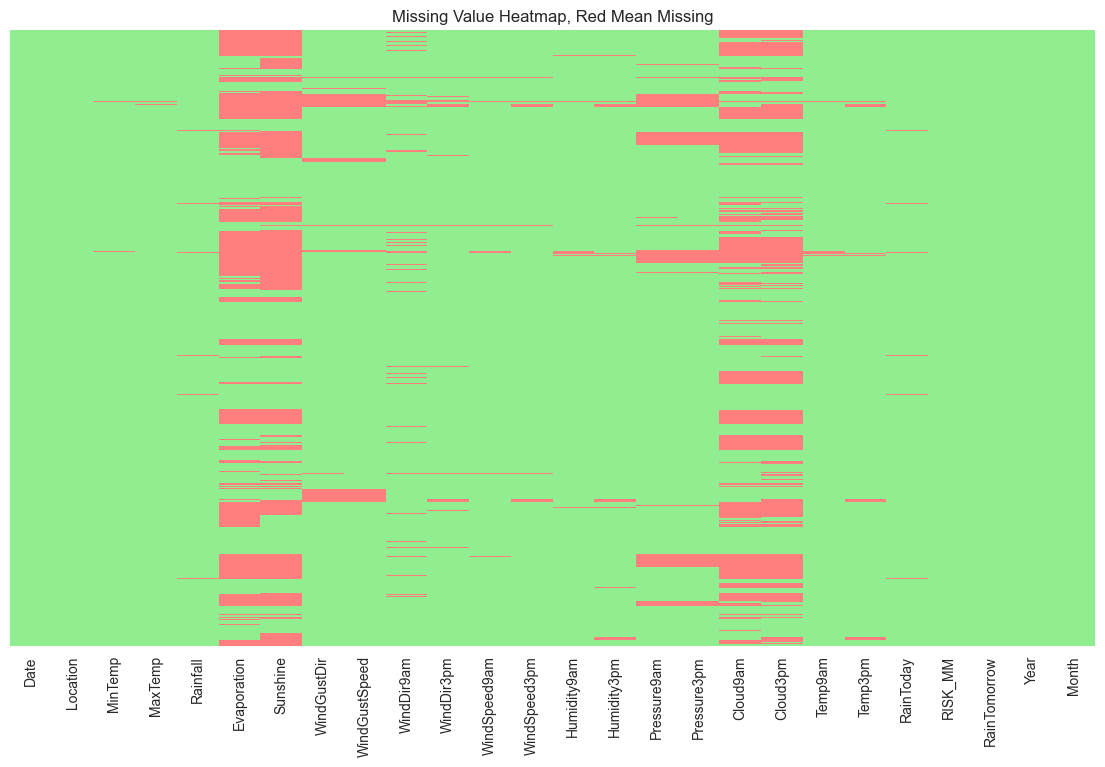

C:\Users\USER\AppData\Local\Temp\ipykernel_27836\615957085.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Month', y='Rainfall', data=data, estimator=sum, ci=None, palette='Blues_d')
C:\Users\USER\AppData\Local\Temp\ipykernel_27836\615957085.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Rainfall', data=data, estimator=sum, ci=None, palette='Blues_d')


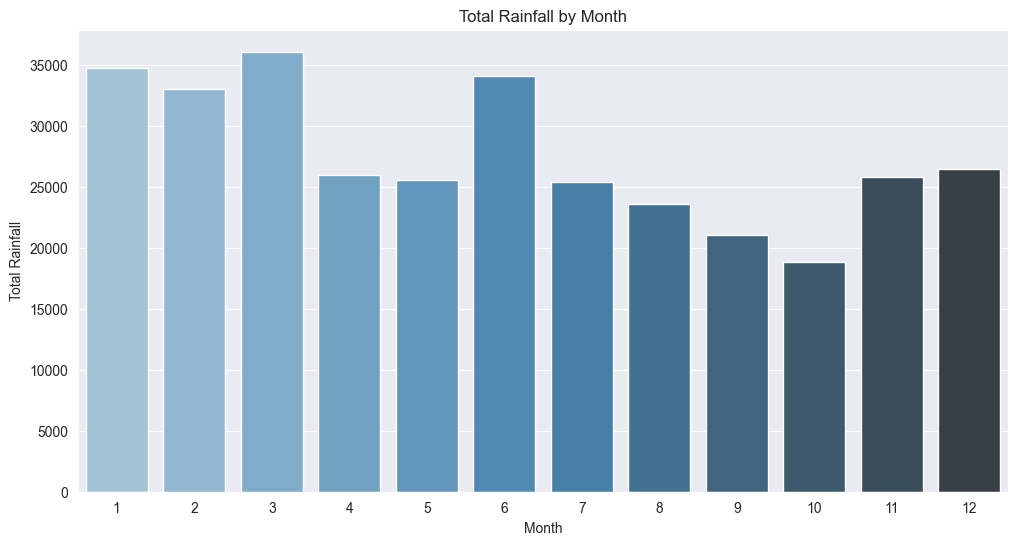

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64
RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64


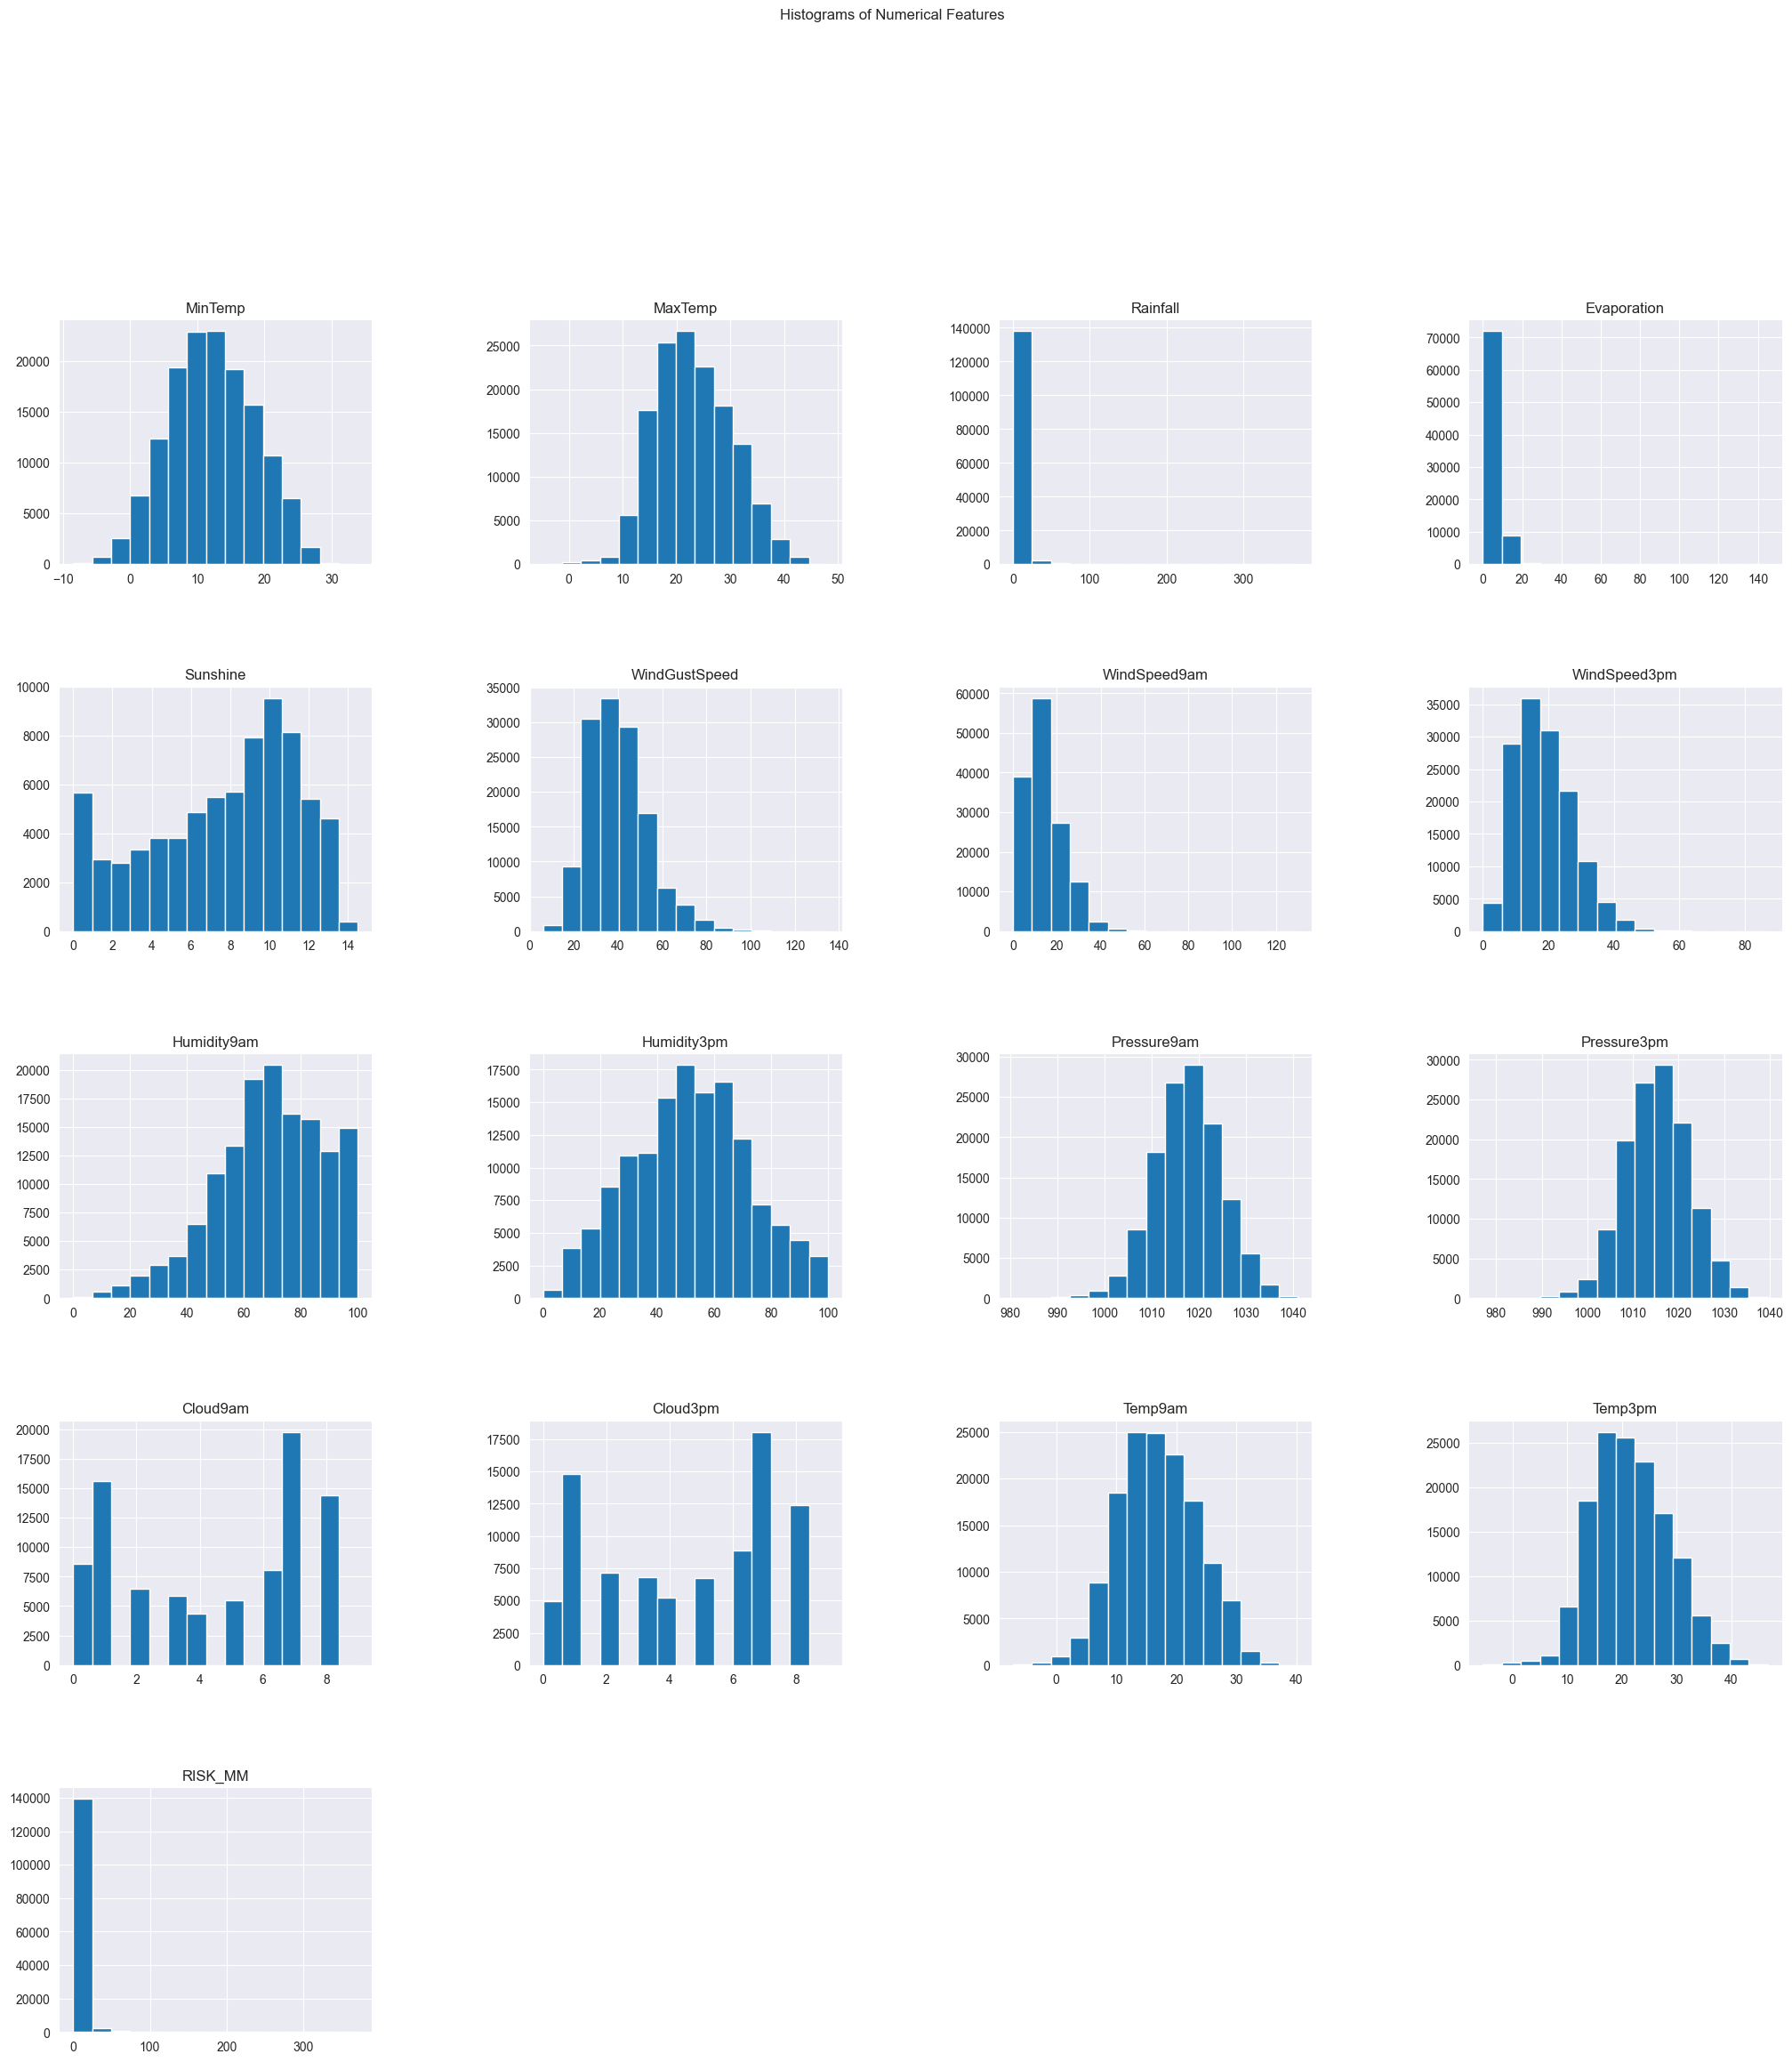

Outlier Counts: 
MinTemp: 62 outliers
MaxTemp: 459 outliers
Rainfall: 25228 outliers
Evaporation: 1954 outliers
Sunshine: 0 outliers
WindGustSpeed: 3006 outliers
WindSpeed9am: 1739 outliers
WindSpeed3pm: 2458 outliers
Humidity9am: 1419 outliers
Humidity3pm: 0 outliers
Pressure9am: 1174 outliers
Pressure3pm: 906 outliers
Cloud9am: 0 outliers
Cloud3pm: 0 outliers
Temp9am: 247 outliers
Temp3pm: 735 outliers
RISK_MM: 25573 outliers


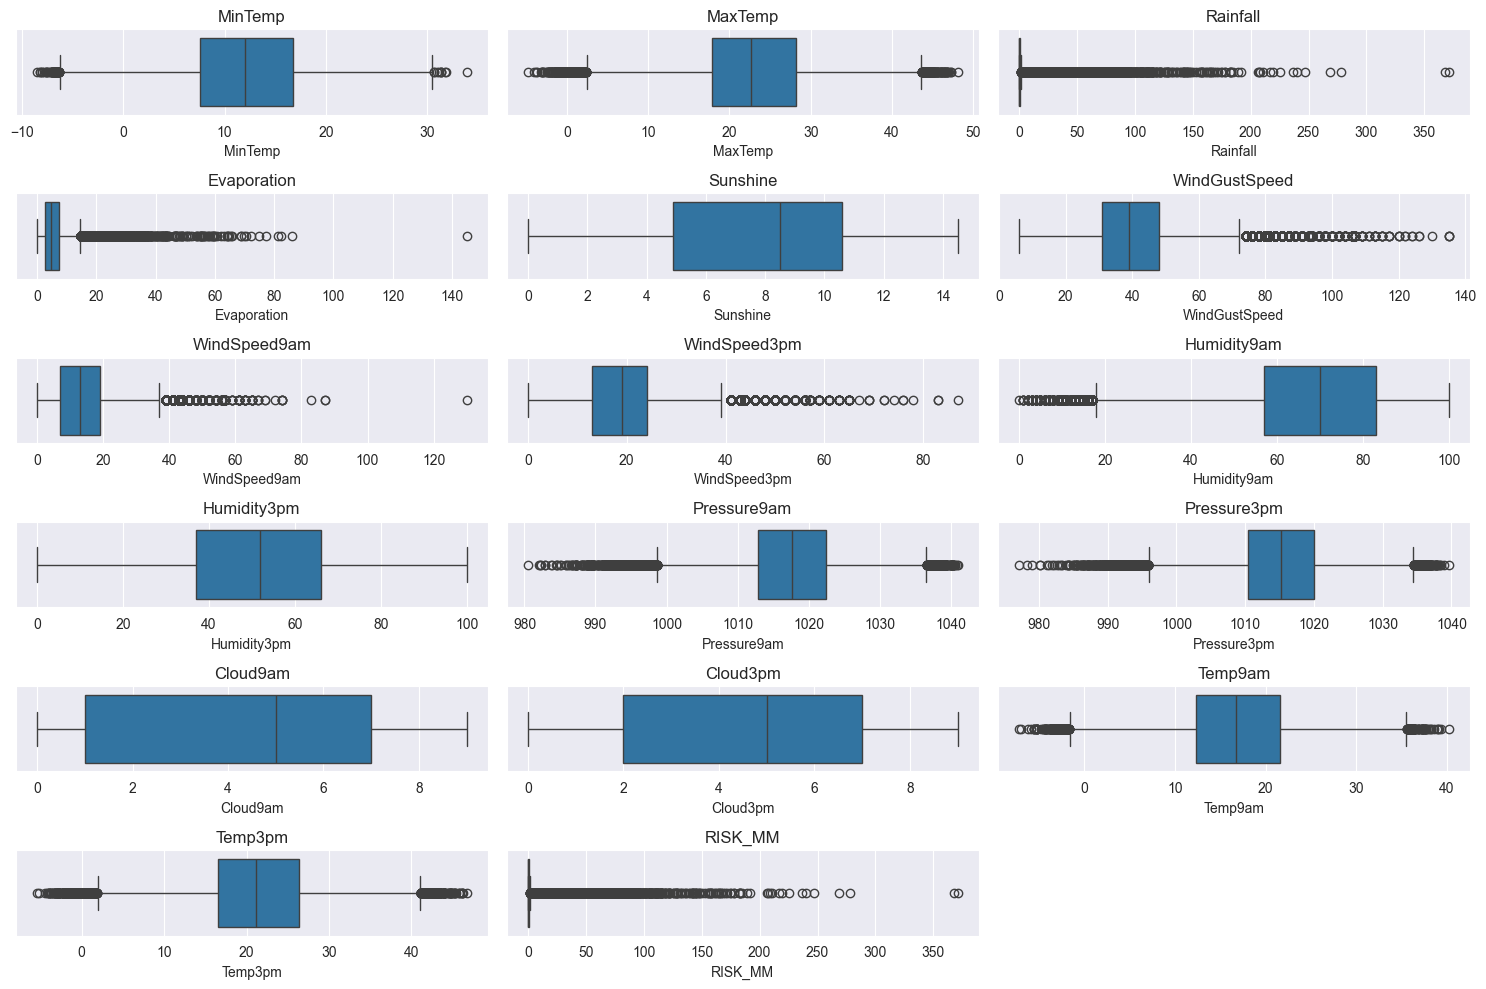

In [3]:
#Initial Data Overview
print(data.info())
print(data.isnull().sum())

data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

#Missing Distribution Heat Map
custom_colors = ['#90EE90', '#FF7F7F']
my_cmap = ListedColormap(custom_colors)
plt.figure(figsize=(14, 8))
sns.heatmap(data.isnull(), cbar=False, cmap=my_cmap, yticklabels=False)
plt.title('Missing Value Heatmap, Red Mean Missing')
plt.show()

#Average Rainfall by Month
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Rainfall', data=data, estimator=sum, ci=None, palette='Blues_d')
plt.title('Total Rainfall by Month')
plt.ylabel('Total Rainfall')
plt.show()

# Raw counts
print(data['RainTomorrow'].value_counts())

# Percentage distribution
print(data['RainTomorrow'].value_counts(normalize=True))


#Histograms of Numerical Features
num_data = data.select_dtypes(include=['int64', 'float64']).columns
data[num_data].hist(bins=15, figsize=(25, 25))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()


def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

num_data = data.select_dtypes(include=['int64', 'float64']).columns
outlier_summary = {}
for col in num_data:
    outlier_count = detect_outliers(data, col).shape[0]
    outlier_summary[col] = outlier_count

# Display outlier counts
print("Outlier Counts: ")
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

# Boxplots Visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_data, 1):
    plt.subplot((len(num_data)//3) + 1, 3, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Data Preprocessing

In [4]:
# Convert to category type
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in categorical_cols:
    data[col] = data[col].astype('category')


# Convert To Date
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d', errors='coerce')
#Extract extra time features from Date:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['Season'] = data['Month']%12 // 3 + 1


#Low Missing use median to replace Null Value
low_missing = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
               'Temp9am', 'Temp3pm']
for columns in low_missing:
    data[columns] = data[columns].fillna(data[columns].median())

data['WindDir3pm'] = data['WindDir3pm'].fillna(data['WindDir3pm'].mode()[0])

#Medium Missing Null Value
numeric_cols = ['WindGustSpeed', 'Pressure9am', 'Pressure3pm']
cat_cols = ['WindGustDir', 'WindDir9am']

# Encode categorical columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
data[cat_cols] = encoder.fit_transform(data[cat_cols])

# Knn
imputer = KNNImputer(n_neighbors=5)
data[numeric_cols + cat_cols] = imputer.fit_transform(data[numeric_cols + cat_cols])

# Round & convert back categorical columns
data[cat_cols] = data[cat_cols].round(0).astype(int)
data[cat_cols] = encoder.inverse_transform(data[cat_cols])


#High Missing Value Replace
column_to_impute = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
features = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Temp9am', 'Temp3pm',
    'Year', 'Month', 'Day', 'DayOfWeek', 'Season'
]
impute_df = data[column_to_impute + features]

# IterativeImputer with RandomForestRegressor
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=35, random_state=10, n_jobs=-1),
    max_iter=7,
    random_state=10,
    initial_strategy='median'
)

# Fit and transform
imputed_array = imputer.fit_transform(impute_df)
imputed_df = pd.DataFrame(imputed_array, columns=impute_df.columns, index=impute_df.index)
data[column_to_impute] = imputed_df[column_to_impute]


data['RainToday'] = data['RainToday'].map({'Yes': 1, 'No': 0})
mask_rain_missing = data['RainToday'].isnull()
data.loc[mask_rain_missing, 'RainToday'] = data.loc[mask_rain_missing, 'Rainfall'].apply(lambda x: 1 if x >= 1.0 else 0)

data.to_csv("Clean.csv")

C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### Feature Engineering

In [5]:
data = pd.read_csv("../data/Clean.csv")
cols_to_drop = ['Unnamed: 0', 'Year', 'WindDir9am', 'WindDir3pm','WindGustDir', 'RainTomorrow']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

# Sort By Date
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by=['Date', 'Location'])

# Generate rolling window features, Sum Rainfall, Mean Temp
for window in [7, 14, 30]:
    data[f'Rain_Sum_{window}d'] = data.groupby('Location')['Rainfall'].transform(lambda x: x.rolling(window).sum())
    data[f'Temp_Mean_{window}d'] = data.groupby('Location')['MaxTemp'].transform(lambda x: x.rolling(window).mean())

# Generate lag features
cols_to_lag = ['Humidity3pm', 'Pressure3pm']
for lag in [1, 3]:
    for col in cols_to_lag:
        data[f'{col}_Lag_{lag}'] = data.groupby('Location')[col].shift(lag)

# Calculate rate of change Deltas
data['Pressure_Diff'] = data.groupby('Location')['Pressure3pm'].diff(3)
data['Humidity_Diff'] = data.groupby('Location')['Humidity3pm'].diff(3)

# Add Cyclical seasonality
data['Month_Sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['Month_Cos'] = np.cos(2 * np.pi * data['Month'] / 12)


# Calculate Intraday Pressure Difference
data['Pressure_Intraday_Diff'] = data['Pressure3pm'] - data['Pressure9am']

# Drop Na to ensure data integrity
data.dropna(inplace=True)


# Encode Location
location_coords = {
    'Albury': (-36.07, 146.91), 'BadgerysCreek': (-33.88, 150.75), 'Cobar': (-31.49, 145.84),
    'CoffsHarbour': (-30.30, 153.11), 'Moree': (-29.46, 149.83), 'Newcastle': (-32.92, 151.78),
    'NorahHead': (-33.28, 151.57), 'NorfolkIsland': (-29.04, 167.95), 'Penrith': (-33.75, 150.70),
    'Richmond': (-33.60, 150.75), 'Sydney': (-33.86, 151.20), 'SydneyAirport': (-33.94, 151.17),
    'WaggaWagga': (-35.12, 147.37), 'Williamtown': (-32.79, 151.84), 'Wollongong': (-34.42, 150.89),
    'Canberra': (-35.28, 149.13), 'Tuggeranong': (-35.42, 149.09), 'MountGinini': (-35.53, 148.77),
    'Ballarat': (-37.56, 143.85), 'Bendigo': (-36.75, 144.27), 'Sale': (-38.10, 147.07),
    'MelbourneAirport': (-37.66, 144.83), 'Melbourne': (-37.81, 144.96), 'Mildura': (-34.20, 142.15),
    'Nhil': (-36.33, 141.65), 'Portland': (-38.36, 141.60), 'Watsonia': (-37.71, 145.08),
    'Dartmoor': (-37.92, 141.27), 'Brisbane': (-27.47, 153.02), 'Cairns': (-16.91, 145.77),
    'GoldCoast': (-28.01, 153.40), 'Townsville': (-19.25, 146.81), 'Adelaide': (-34.92, 138.62),
    'MountGambier': (-37.83, 140.78), 'Nuriootpa': (-34.47, 138.99), 'Woomera': (-31.15, 136.80),
    'Albany': (-35.02, 117.88), 'Witchcliffe': (-34.03, 115.10), 'PearceRAAF': (-31.67, 116.03),
    'PerthAirport': (-31.93, 115.96), 'Perth': (-31.95, 115.86), 'SalmonGums': (-32.98, 121.64),
    'Walpole': (-34.97, 116.73), 'Hobart': (-42.88, 147.32), 'Launceston': (-41.44, 147.14),
    'AliceSprings': (-23.69, 133.87), 'Darwin': (-12.46, 130.84), 'Katherine': (-14.46, 132.26),
    'Uluru': (-25.34, 131.03)
}

# Apply to dataset
data['Loc_Lat'] = data['Location'].map(lambda x: location_coords.get(x, (np.nan, np.nan))[0])
data['Loc_Long'] = data['Location'].map(lambda x: location_coords.get(x, (np.nan, np.nan))[1])

# ==========================================
# Target Engineering
# ==========================================

data['Rainfall'] = data['Rainfall'].clip(lower=0)

# 1. Calculate Rolling 30
data['R30'] = data.groupby('Location')['Rainfall'].transform(
    lambda x: x.rolling(window=30, min_periods=30).sum().shift(1)
)

# Remove the first 30 days with no data
data.dropna(subset=['R30'], inplace=True)


def calculate_spi(df, train_fraction=0.8):
    split_date = df.iloc[int(len(df) * train_fraction)]['Date']
    train_mask = df['Date'] <= split_date
    # Gamma Fit
    def fit_gamma(x):
        valid = x[np.isfinite(x)]
        pos = valid[valid > 0]
        if len(pos) < 15 or np.var(pos) == 0: return None
        try:
            return (*gamma.fit(pos, floc=0), np.mean(valid == 0))
        except:
            return None

    # 3. Calculate Parameters on Training Data
    params = df[train_mask].groupby(['Location', 'Month'])['R30'].apply(fit_gamma)

    # 4. Define Transform Function to Apply SPI
    def apply_spi(row):
        p = params.get((row['Location'], row['Month']))
        if not p or not np.isfinite(row['R30']) or row['R30'] < 0: return np.nan
        shape, loc, scale, prob_zero = p

        if row['R30'] == 0:
            cdf = prob_zero
        else:
            cdf = prob_zero + (1 - prob_zero) * gamma.cdf(row['R30'], shape, loc=loc, scale=scale)

        return norm.ppf(np.clip(cdf, 1e-5, 1 - 1e-5))

    return df.apply(apply_spi, axis=1)


# Usage
data['SPI_1'] = calculate_spi(data)


# Clean numerical issues
data = data.replace([np.inf, -np.inf], np.nan)
data.dropna(subset=['SPI_1'], inplace=True)

# Define Risks
data['Hydrological_Risk'] = 0  # Normal
data.loc[data['SPI_1'] < -1, 'Hydrological_Risk'] = 1 # Meteorological Drought Risk
data.loc[data['SPI_1'] > 1, 'Hydrological_Risk'] = 2  # Pluvial Flood Risk

# Forecast Lag
FORECAST_LAG = -3
data['Hydrological_Risk_Forecast'] = (
    data.groupby('Location')['Hydrological_Risk'].shift(FORECAST_LAG)
)
data.dropna(subset=['Hydrological_Risk_Forecast'], inplace=True)
data['Hydrological_Risk_Forecast'] = data['Hydrological_Risk_Forecast'].astype(int)


# Add SPI Trend
data['SPI_Diff'] = data.groupby('Location')['SPI_1'].diff(3)
data.dropna(subset=['SPI_Diff'], inplace=True)


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\scipy\stats\_continuous_distns.py:3739: RuntimeWarning: invalid value encountered in log
  a = optimize.brentq(lambda a: np.log(a) - sc.digamma(a) - s,


### Splitting

In [6]:
# Drop columns that are either targets, future leaks, or identifiers
drop_cols = ['Date', 'Hydrological_Risk', 'Hydrological_Risk_Forecast',
             'R30', 'RISK_MM', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
             'Temp9am', 'Temp3pm', 'Pressure9am', 'Pressure3pm',
             'Day', 'DayOfWeek', 'Season', 'Month', 'Humidity9am','Location']

X = data.drop(columns=[c for c in drop_cols if c in data.columns])
y = data['Hydrological_Risk_Forecast']

print(f"Total Samples: {len(data)}")

# Time Series Split Ratios (80% Train, 12% Validate, 8% Test)
n = len(X)
train_end = int(n * 0.80)
val_end = int(n * 0.92)

X_train_raw = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val_raw = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test_raw = X.iloc[val_end:]
y_test = y.iloc[val_end:]


# Scale
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

print(f"Train Size: {len(X_train)} ")
print(f"Val Size:   {len(X_val)}  ")
print(f"Test Size:  {len(X_test)} ")

#Numpy For LSTM
XS_train_lstm = scaler.fit_transform(X_train_raw)
XS_val_lstm = scaler.transform(X_val_raw)
XS_test_lstm = scaler.transform(X_test_raw)

# Resampling
under = RandomUnderSampler(sampling_strategy='auto', random_state=100)
X_train_resampled, y_train_resampled = under.fit_resample(X_train, y_train)
print("Applying Auto Undersampling")
print(f"Original Train: {Counter(y_train)}")
print(f"Resampled Train: {Counter(y_train_resampled)}")
x_train_under, y_train_under = under.fit_resample(X_train, y_train)

Total Samples: 138517
Train Size: 110813 
Val Size:   16622  
Test Size:  11082 
Applying Auto Undersampling
Original Train: Counter({0: 74313, 2: 19085, 1: 17415})
Resampled Train: Counter({0: 17415, 1: 17415, 2: 17415})


## Random Forest

In [7]:
# Base Model Training
RandomForest = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    min_samples_split=5,
    n_jobs=-1,
    random_state=40
)

print("Training Base Random Forest")
RandomForest.fit(x_train_under, y_train_under)

# Evaluation
y_pred = RandomForest.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average='macro')


# Accuracy Score and f1 Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nBase Model Accuracy: {accuracy:.2%}")
print(f"Base Model F1 Score (Macro): {f1_macro:.4f}")

# Classification Report
print("\nRandom Forest Base Classification Report")
print(classification_report(y_test, y_pred))

y_test_pred = RandomForest.predict(X_test)
y_train_pred = RandomForest.predict(x_train_under)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
train_acc = accuracy_score(y_train_under, y_train_pred)
train_f1 = f1_score(y_train_under, y_train_pred, average='macro')

print(" Overfitting CHeck")
print("-" * 35)
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy  : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro : {train_f1:.4f}")
print(f"Test F1-Macro  : {test_f1:.4f}")
print("-" * 35)


Training Base Random Forest

Base Model Accuracy: 84.52%
Base Model F1 Score (Macro): 0.8279

Random Forest Base Classification Report
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      6889
           1       0.74      0.81      0.77      2256
           2       0.79      0.90      0.84      1937

    accuracy                           0.85     11082
   macro avg       0.81      0.85      0.83     11082
weighted avg       0.85      0.85      0.85     11082

 Overfitting CHeck
-----------------------------------
Train Accuracy : 85.10%
Test Accuracy  : 84.52%
-----------------------------------
Train F1-Macro : 0.8525
Test F1-Macro  : 0.8279
-----------------------------------


### Random Forest Optuna Hyper Parameter Tuning & Final Model

In [8]:
sampler = TPESampler(seed=40)
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 350),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'n_jobs': -1,
        'random_state': 40,
    }

    # Pipeline with Resampling
    pipeline = ImbPipeline([
        ('under', RandomUnderSampler(random_state=100)),
        ('model', RandomForestClassifier(**param))
    ])

    tscv = TimeSeriesSplit(n_splits=3)
    scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='f1_macro')

    return scores.mean()


print("Starting Optuna Hyperparameter Tuning (Random Forest)")
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)


# Final Model Training
print("\nRetraining model with best parameters")
best_params = study.best_params

fixed_params = {
    'n_jobs': -1,
    'random_state': 40
}

final_params = {**best_params, **fixed_params}

RandomForest_tuned = RandomForestClassifier(**final_params)

# 3. Fit the Model
RandomForest_tuned.fit(
    X_train_resampled,
    y_train_resampled
)
print("Tuned Model Training Complete.")

[I 2026-01-20 00:33:08,852] A new study created in memory with name: no-name-0d88d959-f4d2-46d4-b28f-167f7fea1bcb


Starting Optuna Hyperparameter Tuning (Random Forest)


[I 2026-01-20 00:33:17,910] Trial 0 finished with value: 0.7775494561985227 and parameters: {'n_estimators': 202, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': None, 'criterion': 'entropy', 'bootstrap': False}. Best is trial 0 with value: 0.7775494561985227.
[I 2026-01-20 00:33:22,013] Trial 1 finished with value: 0.798569941675742 and parameters: {'n_estimators': 250, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini', 'bootstrap': False}. Best is trial 1 with value: 0.798569941675742.
[I 2026-01-20 00:33:25,352] Trial 2 finished with value: 0.7955456982868717 and parameters: {'n_estimators': 268, 'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'gini', 'bootstrap': True}. Best is trial 1 with value: 0.798569941675742.
[I 2026-01-20 00:33:27,858] Trial 3 finished with value: 0.7738104208534429 and parameters: {'n_estimators': 236, 'max_depth'

Best Hyperparameters:
{'n_estimators': 250, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini', 'bootstrap': False}

Retraining model with best parameters
Tuned Model Training Complete.


### Random Forest Evaluation


Result 
Test Accuracy : 85.10%
Test  F1-Macro: 0.8346

              precision    recall  f1-score   support

      Normal       0.91      0.85      0.88      6889
     Drought       0.74      0.82      0.78      2256
       Flood       0.80      0.90      0.85      1937

    accuracy                           0.85     11082
   macro avg       0.82      0.86      0.83     11082
weighted avg       0.86      0.85      0.85     11082


Overfitting Check 
-----------------------------------
Train Accuracy :   88.42%
Test Accuracy : 85.10%
-----------------------------------
Train F1-Macro: 0.8853
Test  F1-Macro: 0.8346
-----------------------------------


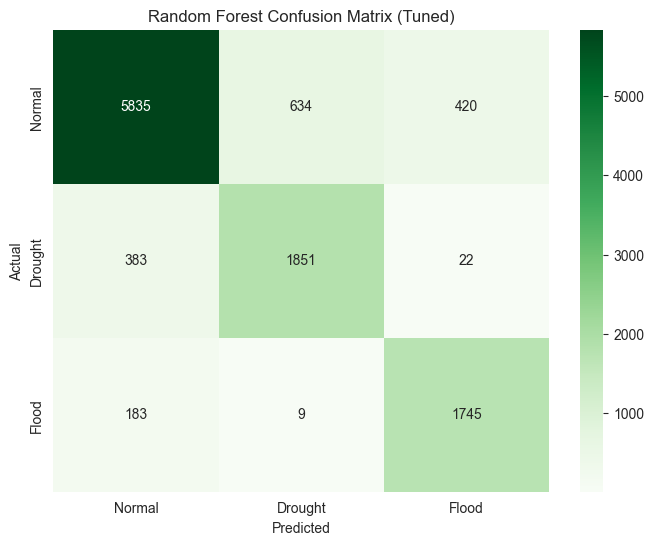

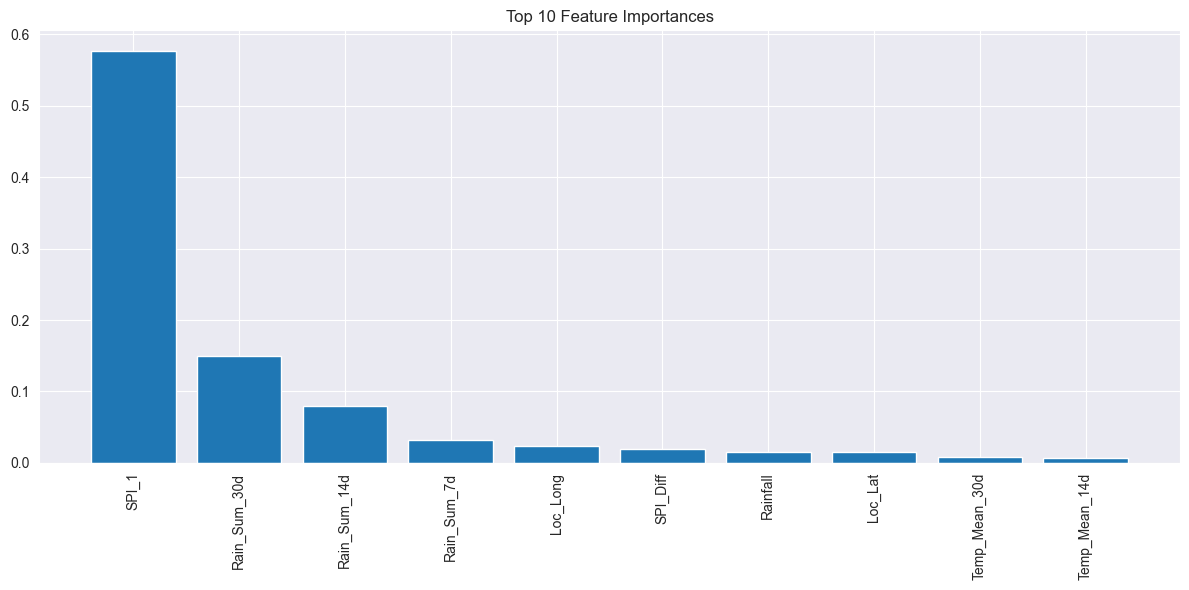


 Top 10 Features 
1. SPI_1: 0.5768
2. Rain_Sum_30d: 0.1494
3. Rain_Sum_14d: 0.0793
4. Rain_Sum_7d: 0.0316
5. Loc_Long: 0.0242
6. SPI_Diff: 0.0190
7. Rainfall: 0.0148
8. Loc_Lat: 0.0146
9. Temp_Mean_30d: 0.0083
10. Temp_Mean_14d: 0.0070
11. Humidity3pm: 0.0064
12. Temp_Mean_7d: 0.0058
13. RainToday: 0.0056
14. Month_Sin: 0.0054
15. Sunshine: 0.0048
16. Pressure3pm_Lag_1: 0.0047
17. Month_Cos: 0.0046
18. MinTemp: 0.0044
19. Humidity3pm_Lag_3: 0.0043
20. Humidity3pm_Lag_1: 0.0043
21. Humidity_Diff: 0.0041
22. Pressure3pm_Lag_3: 0.0037
23. MaxTemp: 0.0034
24. Pressure_Diff: 0.0033
25. Evaporation: 0.0030
26. Cloud3pm: 0.0027
27. Cloud9am: 0.0024
28. Pressure_Intraday_Diff: 0.0021
Files saved successfully!


In [9]:
# Predict on Test
y_pred = RandomForest_tuned.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

# Predict on Train
y_train_pred = RandomForest_tuned.predict(X_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

print(f"\nResult ")
print(f"Test Accuracy : {test_acc:.2%}")
print(f"Test  F1-Macro: {test_f1:.4f}\n")


print(classification_report(y_test, y_pred, target_names=['Normal', 'Drought', 'Flood']))

print(f"\nOverfitting Check ")
print("-" * 35)
print(f"Train Accuracy :   {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro: {train_f1:.4f}")
print(f"Test  F1-Macro: {test_f1:.4f}")
print("-" * 35)


# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Drought', 'Flood'],
            yticklabels=['Normal', 'Drought', 'Flood'])
plt.title('Random Forest Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot Feature Importance
importances = RandomForest_tuned.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
plt.figure(figsize=(12, 6))
plt.title("Top 10 Feature Importances")
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), X_train.columns[indices[:top_n]], rotation=90)
plt.tight_layout()
plt.show()

# Print Top Features
print("\n Top 10 Features ")
feature_names = X_train.columns
for i in range(len(indices)):
    print(f"{i + 1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Retaining the same file names as requested
joblib.dump(RandomForest_tuned, '../model/RandomForest_spi.pkl')
joblib.dump(scaler, '../model/RandomForest_scaler.pkl')
model_columns = list(X_train.columns)
joblib.dump(model_columns, '../model/RandomForest_columns.pkl')
print("Files saved successfully!")

plt.close('all')

## XGBoost

In [10]:
# 5. Base Model Training
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    tree_method='hist',
    device='cuda',
    n_jobs=-1,
    random_state=40
)
print("Training Base XGBoost")
xgb_model.fit(x_train_under, y_train_under)


# Evaluation
y_pred = xgb_model.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average='macro')

# Accuracy Score and F1 score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nBase Model Accuracy: {accuracy:.2%}")
print(f"Base Model F1 Score (Macro): {f1_macro:.4f}")

# Classification Report
print("\nXGBoost Base Classification Report")
print(classification_report(y_test, y_pred))


y_test_pred = xgb_model.predict(X_test)
y_train_pred = xgb_model.predict(x_train_under)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
train_acc = accuracy_score(y_train_under, y_train_pred)
train_f1 = f1_score(y_train_under, y_train_pred, average='macro')

print(" Overfitting Check")
print("-" * 35)
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy  : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro : {train_f1:.4f}")
print(f"Test F1-Macro  : {test_f1:.4f}")
print("-" * 35)

Training Base XGBoost

Base Model Accuracy: 84.13%
Base Model F1 Score (Macro): 0.8273

XGBoost Base Classification Report
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      6889
           1       0.71      0.85      0.77      2256
           2       0.79      0.91      0.84      1937

    accuracy                           0.84     11082
   macro avg       0.80      0.86      0.83     11082
weighted avg       0.85      0.84      0.84     11082

 Overfitting Check
-----------------------------------
Train Accuracy : 86.59%
Test Accuracy  : 84.13%
-----------------------------------
Train F1-Macro : 0.8668
Test F1-Macro  : 0.8273
-----------------------------------


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\xgboost\core.py:774: UserWarning: [00:34:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


#### Xgboost Optuna Hyper Parameter Tuning & Final Model

In [11]:
sampler = TPESampler(seed=40)
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 350),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        'gamma': trial.suggest_float('gamma', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 1, 7.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 7.0, log=True),

        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'device': 'cuda',
        'n_jobs': -1,
        'random_state': 40,
        'verbosity': 0
    }

    clf = XGBClassifier(**param)

    pipeline = ImbPipeline([
        ('under', RandomUnderSampler(random_state=100)),
        ('model', XGBClassifier(**param))
    ])

    tscv = TimeSeriesSplit(n_splits=3)
    scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='f1_macro')

    return scores.mean()

print("Starting Optuna Hyperparameter Tuning (XGBoost)")
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)



# Final Model Training
print("\nRetraining model with best parameters")
best_params = study.best_params

fixed_params = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'tree_method': 'hist',
    'device': 'cuda',
    'n_jobs': -1,
    'random_state': 40,
    'early_stopping_rounds': 20,
    'eval_metric': ['mlogloss', 'merror'],
}

final_params = {**best_params, **fixed_params}

xgb_model_tuned = XGBClassifier(**final_params)

# 3. Fit the Model
xgb_model_tuned.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled), (X_val, y_val)],
    verbose=False
)
print("Tuned Model Training Complete.")



[I 2026-01-20 00:34:45,743] A new study created in memory with name: no-name-04fac566-ac58-4d1b-b18a-009ecd4cf546


Starting Optuna Hyperparameter Tuning (XGBoost)


[I 2026-01-20 00:34:47,591] Trial 0 finished with value: 0.7958425197682741 and parameters: {'n_estimators': 202, 'max_depth': 3, 'learning_rate': 0.06145183807004629, 'min_child_weight': 21, 'subsample': 0.6351051760901814, 'colsample_bytree': 0.5911736916022297, 'gamma': 4.158397145782873, 'reg_alpha': 3.3665299187361026, 'reg_lambda': 4.533685780380742}. Best is trial 0 with value: 0.7958425197682741.
[I 2026-01-20 00:34:50,656] Trial 1 finished with value: 0.7945593152402849 and parameters: {'n_estimators': 272, 'max_depth': 10, 'learning_rate': 0.03988559657231375, 'min_child_weight': 43, 'subsample': 0.7125935456489596, 'colsample_bytree': 0.5082604040967598, 'gamma': 6.425603303390368, 'reg_alpha': 2.4000136291821197, 'reg_lambda': 1.2603843210938215}. Best is trial 0 with value: 0.7958425197682741.
[I 2026-01-20 00:34:54,118] Trial 2 finished with value: 0.7958126263892821 and parameters: {'n_estimators': 309, 'max_depth': 4, 'learning_rate': 0.01493491208855327, 'min_child_wei

Best Hyperparameters:
{'n_estimators': 137, 'max_depth': 6, 'learning_rate': 0.06665409689180943, 'min_child_weight': 26, 'subsample': 0.6975578235011083, 'colsample_bytree': 0.6150698692147789, 'gamma': 6.593561238844497, 'reg_alpha': 1.3167469977946604, 'reg_lambda': 5.398861415274562}

Retraining model with best parameters
Tuned Model Training Complete.


### XgBoost Evaluation


Result 
Test Accuracy : 84.55%
Test  F1-Macro: 0.8305

              precision    recall  f1-score   support

      Normal       0.92      0.83      0.87      6889
Drought Risk       0.72      0.84      0.78      2256
  Flood Risk       0.79      0.90      0.84      1937

    accuracy                           0.85     11082
   macro avg       0.81      0.86      0.83     11082
weighted avg       0.86      0.85      0.85     11082


 Overfitting Check 
-----------------------------------
Train Accuracy :   85.50%
Test Accuracy : 84.55%
-----------------------------------
Train F1-Macro: 0.8562
Test  F1-Macro: 0.8305


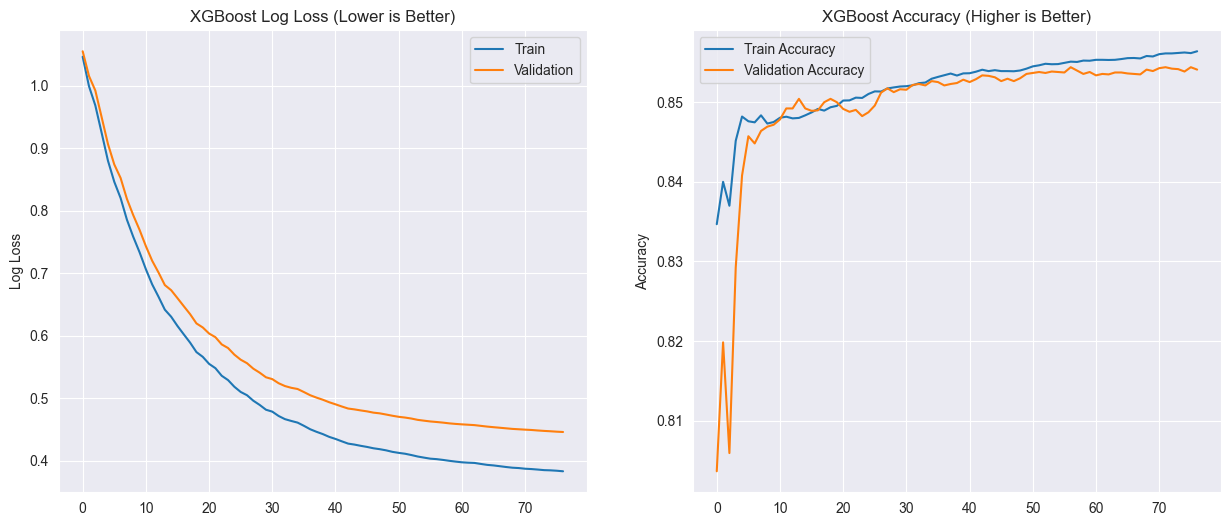

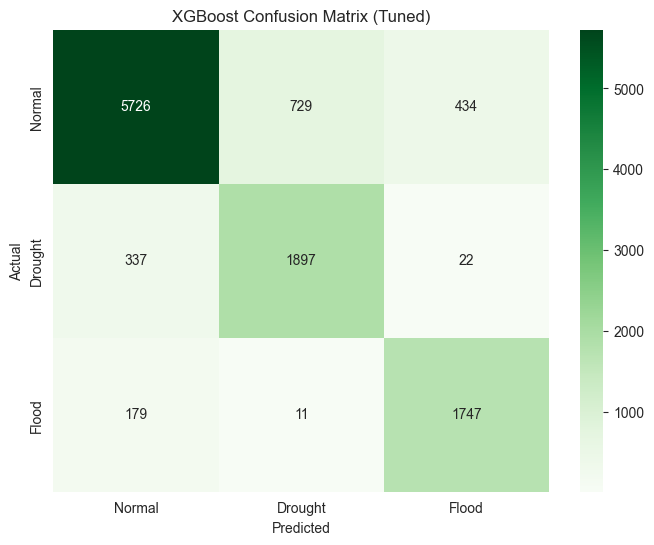

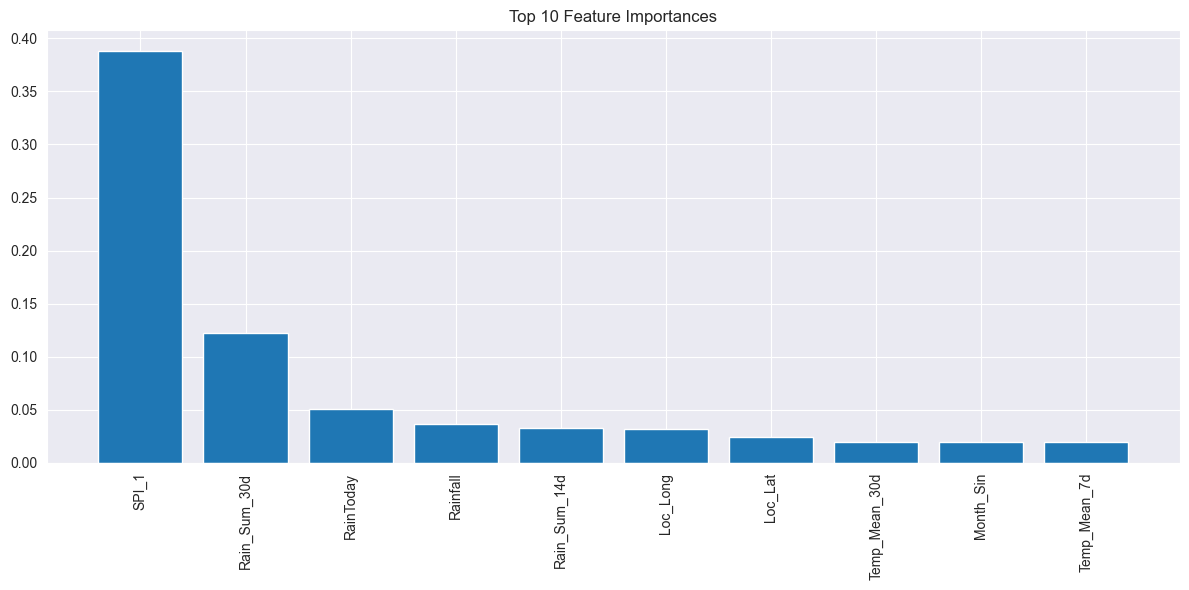


 Top 10 Features 
1. SPI_1: 0.3880
2. Rain_Sum_30d: 0.1221
3. RainToday: 0.0506
4. Rainfall: 0.0369
5. Rain_Sum_14d: 0.0326
6. Loc_Long: 0.0317
7. Loc_Lat: 0.0244
8. Temp_Mean_30d: 0.0199
9. Month_Sin: 0.0197
10. Temp_Mean_7d: 0.0193
11. SPI_Diff: 0.0190
12. Month_Cos: 0.0189
13. Humidity3pm: 0.0189
14. Rain_Sum_7d: 0.0184
15. Temp_Mean_14d: 0.0171
16. Sunshine: 0.0166
17. Humidity3pm_Lag_1: 0.0157
18. MinTemp: 0.0148
19. Humidity_Diff: 0.0147
20. Cloud3pm: 0.0141
21. MaxTemp: 0.0134
22. Humidity3pm_Lag_3: 0.0131
23. Evaporation: 0.0111
24. Pressure3pm_Lag_1: 0.0111
25. Pressure_Diff: 0.0099
26. Pressure3pm_Lag_3: 0.0097
27. Cloud9am: 0.0091
28. Pressure_Intraday_Diff: 0.0091
Files saved successfully!


In [12]:
# Predict on Test
y_pred = xgb_model_tuned.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

# Predict on Train
y_train_pred = xgb_model_tuned.predict(X_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

# Result
print(f"\nResult ")
print(f"Test Accuracy : {test_acc:.2%}")
print(f"Test  F1-Macro: {test_f1:.4f}\n")

# Clasification Report
print(classification_report(y_test, y_pred,
    target_names=['Normal', 'Drought Risk', 'Flood Risk']))


print(f"\n Overfitting Check ")
print("-" * 35)
print(f"Train Accuracy :   {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro: {train_f1:.4f}")
print(f"Test  F1-Macro: {test_f1:.4f}")



# Plotting Results
results = xgb_model_tuned.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Log Loss Plot
ax[0].plot(x_axis, results['validation_0']['mlogloss'], label='Train')
ax[0].plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
ax[0].legend()
ax[0].set_ylabel('Log Loss')
ax[0].set_title('XGBoost Log Loss (Lower is Better)')
ax[0].grid(True)

# Accuracy Plot
train_acc = [1 - x for x in results['validation_0']['merror']]
val_acc   = [1 - x for x in results['validation_1']['merror']]
ax[1].plot(x_axis, train_acc, label='Train Accuracy')
ax[1].plot(x_axis, val_acc, label='Validation Accuracy')
ax[1].legend()
ax[1].set_ylabel('Accuracy')
ax[1].set_title('XGBoost Accuracy (Higher is Better)')
ax[1].grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
xticklabels=['Normal', 'Drought', 'Flood'],
yticklabels=['Normal', 'Drought', 'Flood'])
plt.title('XGBoost Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot Feature Importance
importances = xgb_model_tuned.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
plt.figure(figsize=(12, 6))
plt.title("Top 10 Feature Importances")
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), X_train.columns[indices[:top_n]], rotation=90)
plt.tight_layout()
plt.show()

# Print Top Features
print("\n Top 10 Features ")
feature_names = X_train.columns
for i in range(len(indices)):
    print(f"{i + 1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

joblib.dump(xgb_model_tuned, '../model/xgb_model_spi.pkl')
joblib.dump(scaler, '../model/xgb_model_scaler.pkl')
model_columns = list(X_train.columns)
joblib.dump(model_columns, '../model/xgb_model_columns.pkl')
print("Files saved successfully!")

plt.close('all')

## LSTM

In [13]:
# Base LSTM Model Training
# Reshape for LSTM
X_train_lstm = X_train_resampled.values.reshape((X_train_resampled.shape[0], 1, X_train_resampled.shape[1]))
X_val_lstm = XS_val_lstm.reshape((XS_val_lstm.shape[0], 1, XS_val_lstm.shape[1]))
X_test_lstm = XS_test_lstm.reshape((XS_test_lstm.shape[0], 1, XS_test_lstm.shape[1]))

# Convert labels to categorical for multi-class classification
y_train_cat = to_categorical(y_train_resampled, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

def create_lstm_model(units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, input_shape=(1, X_train_resampled.shape[1]), return_sequences=True),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dropout(dropout),
        Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("Training Base LSTM")
lstm_model = create_lstm_model(units=64, dropout=0.3, learning_rate=0.001)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = lstm_model.fit(
    X_train_lstm, y_train_cat,
    validation_data=(X_val_lstm, y_val_cat),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluation
y_pred_prob = lstm_model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

f1_macro = f1_score(y_test_labels, y_pred, average='macro')
accuracy = accuracy_score(y_test_labels, y_pred)

print(f"\nBase Model Accuracy: {accuracy:.2%}")
print(f"Base Model F1 Score (Macro): {f1_macro:.4f}")

# Classification Report
print("\nLSTM Base Classification Report")
print(classification_report(y_test_labels, y_pred))

# Overfitting Check
y_train_pred_prob = lstm_model.predict(X_train_lstm)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_train_labels = np.argmax(y_train_cat, axis=1)

test_acc = accuracy_score(y_test_labels, y_pred)
test_f1 = f1_score(y_test_labels, y_pred, average='macro')
train_acc = accuracy_score(y_train_labels, y_train_pred)
train_f1 = f1_score(y_train_labels, y_train_pred, average='macro')

print("\nOverfitting Check")
print("-" * 35)
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy  : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro : {train_f1:.4f}")
print(f"Test F1-Macro  : {test_f1:.4f}")
print("-" * 35)


Training Base LSTM
Epoch 1/50
817/817 [==============================] - 14s 6ms/step - loss: 0.5424 - accuracy: 0.7778 - val_loss: 0.4819 - val_accuracy: 0.8075 - lr: 0.0010
Epoch 2/50
817/817 [==============================] - 5s 6ms/step - loss: 0.4355 - accuracy: 0.8338 - val_loss: 0.4658 - val_accuracy: 0.8214 - lr: 0.0010
Epoch 3/50
817/817 [==============================] - 4s 5ms/step - loss: 0.4251 - accuracy: 0.8387 - val_loss: 0.4696 - val_accuracy: 0.8219 - lr: 0.0010
Epoch 4/50
817/817 [==============================] - 4s 5ms/step - loss: 0.4223 - accuracy: 0.8404 - val_loss: 0.4707 - val_accuracy: 0.8205 - lr: 0.0010
Epoch 5/50
817/817 [==============================] - 4s 5ms/step - loss: 0.4171 - accuracy: 0.8409 - val_loss: 0.4617 - val_accuracy: 0.8252 - lr: 0.0010
Epoch 6/50
817/817 [==============================] - 4s 5ms/step - loss: 0.4138 - accuracy: 0.8421 - val_loss: 0.4508 - val_accuracy: 0.8325 - lr: 0.0010
Epoch 7/50
817/817 [==============================

### LSTM Optuna Hyper Parameter Tuning & Final Model

In [14]:
sampler = TPESampler(seed=50)
def objective(trial):
    # Suggest hyperparameters
    units = trial.suggest_int('units', 32, 128, step=32)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Create model
    model = create_lstm_model(units=units, dropout=dropout, learning_rate=learning_rate)

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_lstm, y_train_cat,
        validation_data=(X_val_lstm, y_val_cat),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    y_val_pred_prob = model.predict(X_val_lstm, verbose=0)
    y_val_pred = np.argmax(y_val_pred_prob, axis=1)
    y_val_labels = np.argmax(y_val_cat, axis=1)

    f1 = f1_score(y_val_labels, y_val_pred, average='macro')

    return f1


print("\nStarting Optuna Hyperparameter Tuning (LSTM)")
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)

# Final Model Training
print("\nRetraining model with best parameters")
best_params = study.best_params

lstm_model_tuned = create_lstm_model(
    units=best_params['units'],
    dropout=best_params['dropout'],
    learning_rate=best_params['learning_rate']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

history_tuned = lstm_model_tuned.fit(
    X_train_lstm, y_train_cat,
    validation_data=(X_val_lstm, y_val_cat),
    epochs=50,
    batch_size=best_params['batch_size'],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Tuned Model Training Complete.")

[I 2026-01-20 00:37:53,446] A new study created in memory with name: no-name-0811a4d1-6004-441e-aead-5245b1fe7af1



Starting Optuna Hyperparameter Tuning (LSTM)


[I 2026-01-20 00:39:14,129] Trial 0 finished with value: 0.8255645389926612 and parameters: {'units': 64, 'dropout': 0.2684249313348009, 'learning_rate': 0.00032430067119108353, 'batch_size': 128}. Best is trial 0 with value: 0.8255645389926612.
[I 2026-01-20 00:39:51,321] Trial 1 finished with value: 0.8290512423063227 and parameters: {'units': 64, 'dropout': 0.4315681984519141, 'learning_rate': 0.003319505373602711, 'batch_size': 128}. Best is trial 1 with value: 0.8290512423063227.
[I 2026-01-20 00:40:34,640] Trial 2 finished with value: 0.8196559014624266 and parameters: {'units': 32, 'dropout': 0.4917994054152351, 'learning_rate': 0.006581984814494731, 'batch_size': 128}. Best is trial 1 with value: 0.8290512423063227.
[I 2026-01-20 00:41:27,083] Trial 3 finished with value: 0.8251520484383364 and parameters: {'units': 96, 'dropout': 0.3173262342915685, 'learning_rate': 0.00103363747819921, 'batch_size': 64}. Best is trial 1 with value: 0.8290512423063227.
[I 2026-01-20 00:42:33,5

Best Hyperparameters:
{'units': 128, 'dropout': 0.3296006743394243, 'learning_rate': 0.006851038976965681, 'batch_size': 32}

Retraining model with best parameters
Epoch 1/50
1633/1633 [==============================] - 11s 6ms/step - loss: 0.4797 - accuracy: 0.8136 - val_loss: 0.4704 - val_accuracy: 0.8326 - lr: 0.0069
Epoch 2/50
1633/1633 [==============================] - 9s 5ms/step - loss: 0.4447 - accuracy: 0.8330 - val_loss: 0.4750 - val_accuracy: 0.8204 - lr: 0.0069
Epoch 3/50
1633/1633 [==============================] - 9s 5ms/step - loss: 0.4371 - accuracy: 0.8339 - val_loss: 0.4633 - val_accuracy: 0.8296 - lr: 0.0069
Epoch 4/50
1633/1633 [==============================] - 8s 5ms/step - loss: 0.4358 - accuracy: 0.8363 - val_loss: 0.5460 - val_accuracy: 0.7899 - lr: 0.0069
Epoch 5/50
1633/1633 [==============================] - 9s 5ms/step - loss: 0.4304 - accuracy: 0.8365 - val_loss: 0.5298 - val_accuracy: 0.8109 - lr: 0.0069
Epoch 6/50
1633/1633 [============================

### LSTM Evaluation

1633/1633 [==============================] - 3s 2ms/step

Result
Test Accuracy : 83.61%
Test  F1-Macro: 0.8200

              precision    recall  f1-score   support

      Normal       0.91      0.82      0.86      6889
Drought Risk       0.72      0.82      0.77      2256
  Flood Risk       0.76      0.91      0.83      1937

    accuracy                           0.84     11082
   macro avg       0.80      0.85      0.82     11082
weighted avg       0.85      0.84      0.84     11082


Overfitting Check
-----------------------------------
Train Accuracy :   85.20%
Test Accuracy : 83.61%
-----------------------------------
Train F1-Macro: 0.8532
Test  F1-Macro: 0.8200


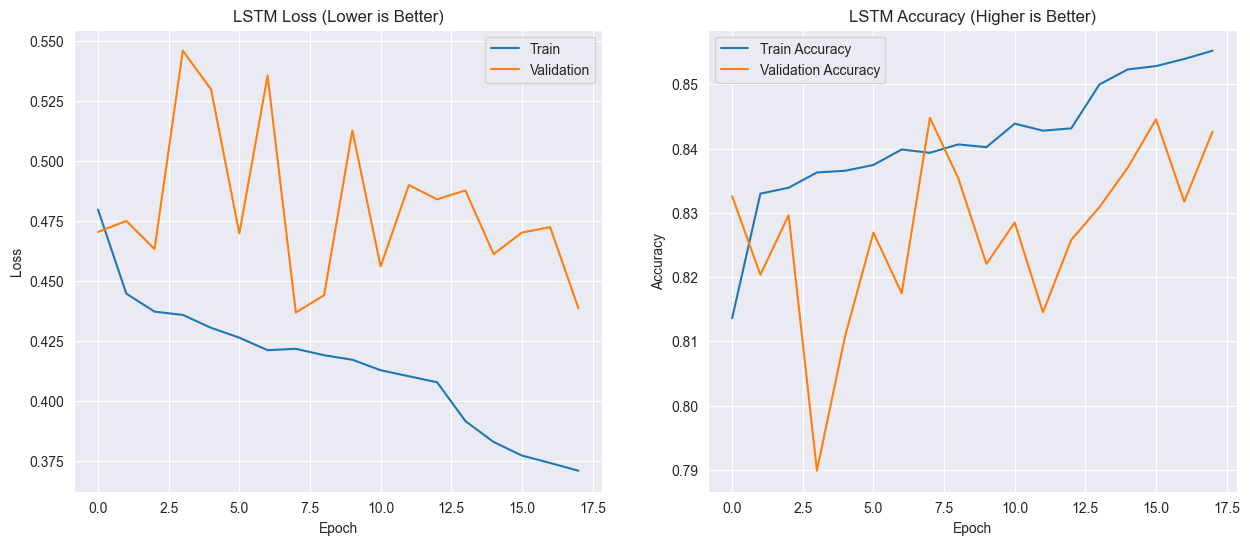

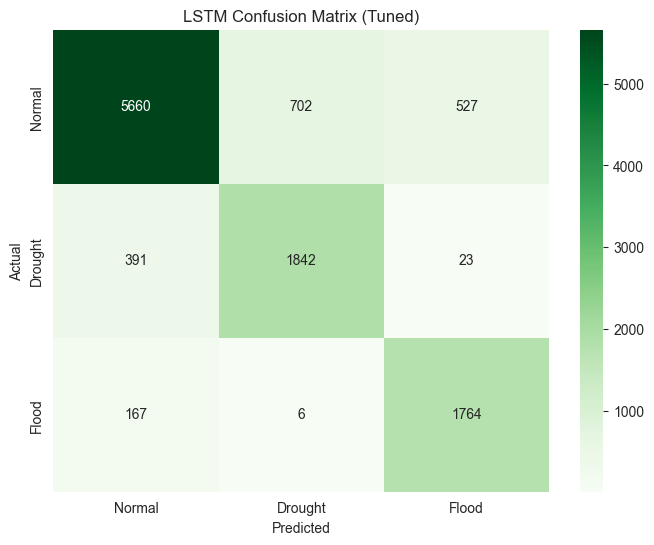

C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\keras\backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


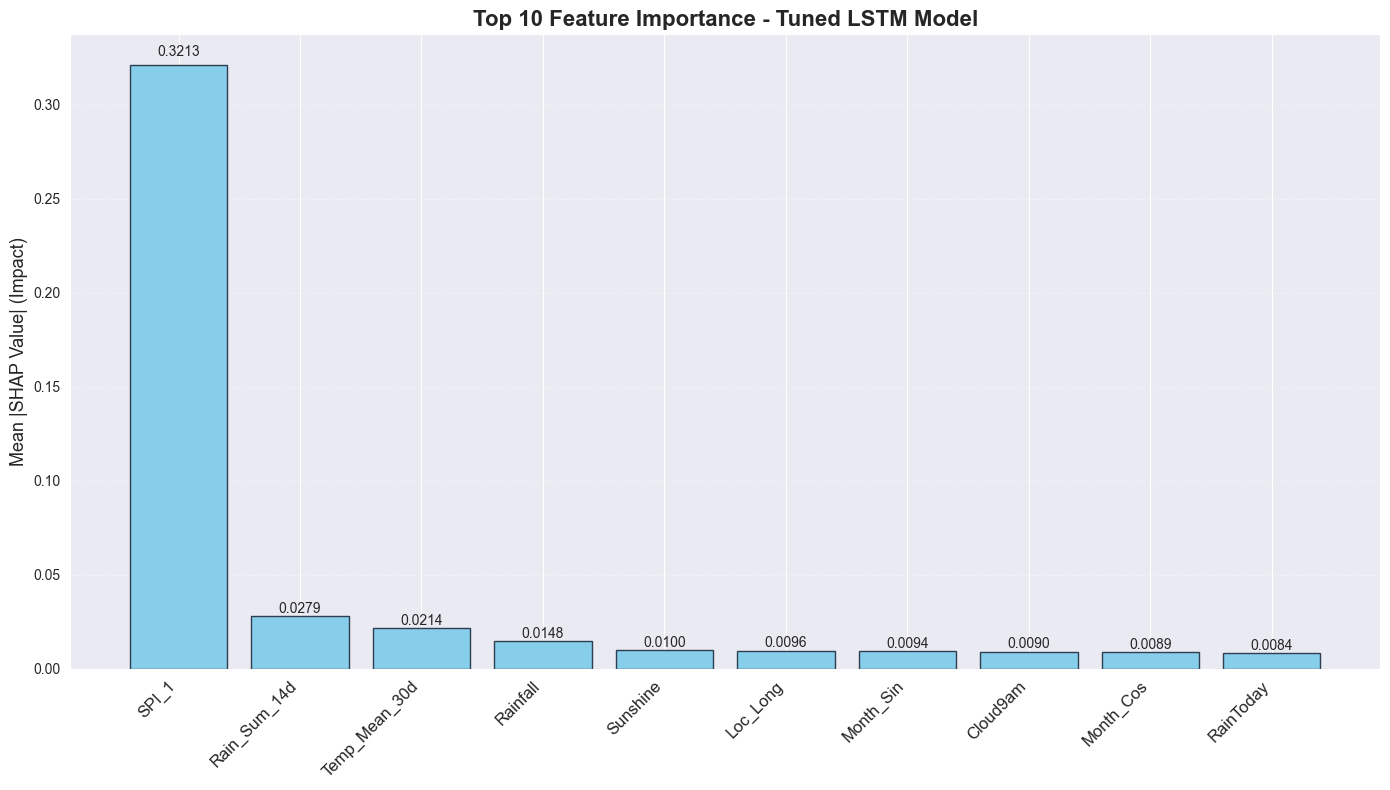

Files saved successfully!


In [15]:
# Predict on Test
y_pred_prob = lstm_model_tuned.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

test_acc = accuracy_score(y_test_labels, y_pred)
test_f1 = f1_score(y_test_labels, y_pred, average='macro')

# Predict on Train
y_train_pred_prob = lstm_model_tuned.predict(X_train_lstm)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_train_labels = np.argmax(y_train_cat, axis=1)

train_acc = accuracy_score(y_train_labels, y_train_pred)
train_f1 = f1_score(y_train_labels, y_train_pred, average='macro')

print(f"\nResult")
print(f"Test Accuracy : {test_acc:.2%}")
print(f"Test  F1-Macro: {test_f1:.4f}\n")

# Classification Report
print(classification_report(y_test_labels, y_pred,
                            target_names=['Normal', 'Drought Risk', 'Flood Risk']))

print(f"\nOverfitting Check")
print("-" * 35)
print(f"Train Accuracy :   {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro: {train_f1:.4f}")
print(f"Test  F1-Macro: {test_f1:.4f}")

# Plotting Results
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Loss Plot
ax[0].plot(history_tuned.history['loss'], label='Train')
ax[0].plot(history_tuned.history['val_loss'], label='Validation')
ax[0].legend()
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_title('LSTM Loss (Lower is Better)')
ax[0].grid(True)

# 2. Accuracy Plot
ax[1].plot(history_tuned.history['accuracy'], label='Train Accuracy')
ax[1].plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
ax[1].legend()
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_title('LSTM Accuracy (Higher is Better)')
ax[1].grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Drought', 'Flood'],
            yticklabels=['Normal', 'Drought', 'Flood'])
plt.title('LSTM Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


#Shsp Plot
# 1. Select Background and Test Samples
background_data = X_train_lstm[np.random.choice(X_train_lstm.shape[0], 200, replace=False)]
X_test_sample = X_test_lstm[:300]

# 2. Compute SHAP
explainer = shap.GradientExplainer(lstm_model_tuned, background_data)
shap_values = explainer.shap_values(X_test_sample)

# 3. Aggregate to get Global Importance
shap_array = np.array(shap_values)
shap_array = shap_array.squeeze(axis=1)
global_importance = np.abs(shap_array).mean(axis=(0, 2))
# 4. Prepare Feature Names
feature_names = X_train_raw.columns.tolist()

# 5. Sort From High to Low and select TOP 10
indices = np.argsort(global_importance)[::-1][:10]
sorted_importance = global_importance[indices]
sorted_features = [feature_names[i] for i in indices]

# 6. Plot Vertical Bar Chart (Top 10)
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(sorted_importance)), sorted_importance, color='#87CEEB', edgecolor='#2c3e50')

# Formatting labels
plt.xticks(range(len(sorted_importance)), sorted_features, rotation=45, ha='right', fontsize=12)
plt.ylabel('Mean |SHAP Value| (Impact)', fontsize=13)
plt.title('Top 10 Feature Importance - Tuned LSTM Model', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add numerical labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01),
             f"{yval:.4f}", ha='center', va='bottom', fontsize=10, rotation=0)

plt.tight_layout()
plt.show()



# Save model and artifacts
lstm_model_tuned.save('model/lstm_model_spi.h5')
joblib.dump(scaler, '../model/lstm_model_scaler.pkl')
model_columns = list(X_train_raw.columns)
joblib.dump(model_columns, '../model/lstm_model_columns.pkl')


print("Files saved successfully!")
plt.close('all')

## TabNet

In [16]:
# Convert to Numpy for TabNet
X_train_np = X_train.values
y_train_np = y_train.values
X_val_np = X_val.values
y_val_np = y_val.values
X_test_np = X_test.values
y_test_np = y_test.values
X_train_resampled, y_train_resampled = under.fit_resample(X_train_np, y_train_np)

# Define Base TabNet Parameters
tabnet_model = TabNetClassifier(
    n_d=16,n_a=16,
    n_steps=3,
    gamma=1.3,
    n_independent=2, n_shared=2,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    device_name='auto',
    verbose=0
)
print("Training Base TabNet")
tabnet_model.fit(
    X_train=X_train_resampled,y_train=y_train_resampled,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['valid'], eval_metric=['accuracy', 'logloss'],
    max_epochs=15,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


# Evaluation
y_pred = tabnet_model.predict(X_test_np)
f1_macro = f1_score(y_test, y_pred, average='macro')

# 1. Accuracy Score And F1 Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nBase Model Accuracy: {accuracy:.2%}")
print(f"Base Model F1 Score (Macro): {f1_macro:.4f}")


# 2. Classification Report
print("\nTabNet Base Classification Report")
print(classification_report(y_test, y_pred))

y_test_pred = tabnet_model.predict(X_test_np)
y_train_pred = tabnet_model.predict(X_train_resampled)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

print(" Overfitting CHeck")
print("-" * 35)
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy  : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro : {train_f1:.4f}")
print(f"Test F1-Macro  : {test_f1:.4f}")
print("-" * 35)


Training Base TabNet

Early stopping occurred at epoch 14 with best_epoch = 9 and best_valid_logloss = 0.42109


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Base Model Accuracy: 83.95%
Base Model F1 Score (Macro): 0.8222

TabNet Base Classification Report
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      6889
           1       0.74      0.80      0.77      2256
           2       0.76      0.91      0.83      1937

    accuracy                           0.84     11082
   macro avg       0.80      0.85      0.82     11082
weighted avg       0.85      0.84      0.84     11082

 Overfitting CHeck
-----------------------------------
Train Accuracy : 84.49%
Test Accuracy  : 83.95%
-----------------------------------
Train F1-Macro : 0.8461
Test F1-Macro  : 0.8222
-----------------------------------


### TabNet Optuna Hyper Parameter Tuning & Final Model

In [17]:
sampler = TPESampler(seed=40)
def objective(trial):
    # TabNet Hyperparameters Search Space
    n_d = trial.suggest_int("n_d", 8, 32)
    n_a = n_d
    n_steps = trial.suggest_int("n_steps", 3, 6)
    gamma_rel = trial.suggest_float("gamma", 1.0, 2.0)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-4, 1e-2, log=True)
    Learning_Rate = trial.suggest_float("lr", 1e-3, 5e-2, log=True)

    # Model instantiation
    clf = TabNetClassifier(
        n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma_rel,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=Learning_Rate),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        device_name='auto',
        verbose=0
    )

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for fold, (train_index, val_index) in enumerate(tscv.split(X_train)):
        X_t_fold, X_v_fold = X_train.iloc[train_index].values, X_train.iloc[val_index].values
        y_t_fold, y_v_fold = y_train.iloc[train_index].values, y_train.iloc[val_index].values
        X_t_res, y_t_res = under.fit_resample(X_t_fold, y_t_fold)

        clf.fit(
            X_train=X_t_res, y_train=y_t_res,
            eval_set=[(X_v_fold, y_v_fold)],
            eval_metric=['accuracy'],
            max_epochs=25,
            patience=5,
            batch_size=512, virtual_batch_size=128,
            num_workers=0
        )

        # Predict
        preds = clf.predict(X_v_fold)
        score = f1_score(y_v_fold, preds, average='macro')
        scores.append(score)

    return np.mean(scores)


print("Starting Optuna Hyperparameter Tuning (TabNet)")
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)


# Final Model Training
print("\nRetraining model with best parameters")
bp = study.best_params

# Re-instantiate with best params
tabnet_model_tuned = TabNetClassifier(
    n_d=bp['n_d'],
    n_a=bp['n_d'],
    n_steps=bp['n_steps'],
    gamma=bp['gamma'],
    lambda_sparse=bp['lambda_sparse'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=bp['lr']),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    device_name='auto',
    verbose=0
)

# Fit Final Model
tabnet_model_tuned.fit(
    X_train=X_train_resampled,
    y_train=y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled), (X_val_np, y_val_np)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy', 'logloss'],
    max_epochs=40,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0
)
print("Tuned Model Training Complete.")

[I 2026-01-20 01:10:50,364] A new study created in memory with name: no-name-4c0bbb09-1942-4c87-af6c-2f59161e1ad9


Starting Optuna Hyperparameter Tuning (TabNet)
Stop training because you reached max_epochs = 25 with best_epoch = 20 and best_val_0_accuracy = 0.81349


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 23 with best_epoch = 18 and best_val_0_accuracy = 0.82081


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...


Early stopping occurred at epoch 19 with best_epoch = 14 and best_val_0_accuracy = 0.83092


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-01-20 01:43:08,882] Trial 14 finished with value: 0.7841866097609037 and parameters: {'n_d': 28, 'n_steps': 6, 'gamma': 1.361218963248301, 'lambda_sparse': 0.0002133287776300852, 'lr': 0.008654990760700552}. Best is trial 10 with value: 0.7919080898165269.


Best Hyperparameters:
{'n_d': 20, 'n_steps': 6, 'gamma': 1.3809921999531714, 'lambda_sparse': 0.0001884557121425747, 'lr': 0.049197153310374796}

Retraining model with best parameters
Stop training because you reached max_epochs = 40 with best_epoch = 32 and best_valid_logloss = 0.42106


C:\Users\USER\anaconda3\envs\tf_10\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Tuned Model Training Complete.


### 8. Evaluation (TabNet)

Result
Test Accuracy : 84.79%
Test  F1-Macro: 0.8325

              precision    recall  f1-score   support

      Normal       0.92      0.84      0.87      6889
Drought Risk       0.73      0.83      0.78      2256
  Flood Risk       0.79      0.91      0.85      1937

    accuracy                           0.85     11082
   macro avg       0.81      0.86      0.83     11082
weighted avg       0.86      0.85      0.85     11082


Overfitting Check
-----------------------------------
Train Accuracy :   84.97%
Test Accuracy : 84.79%
-----------------------------------
Train F1-Macro: 0.8510
Test  F1-Macro: 0.8325
-----------------------------------

Tabnet Confusion Matrix...


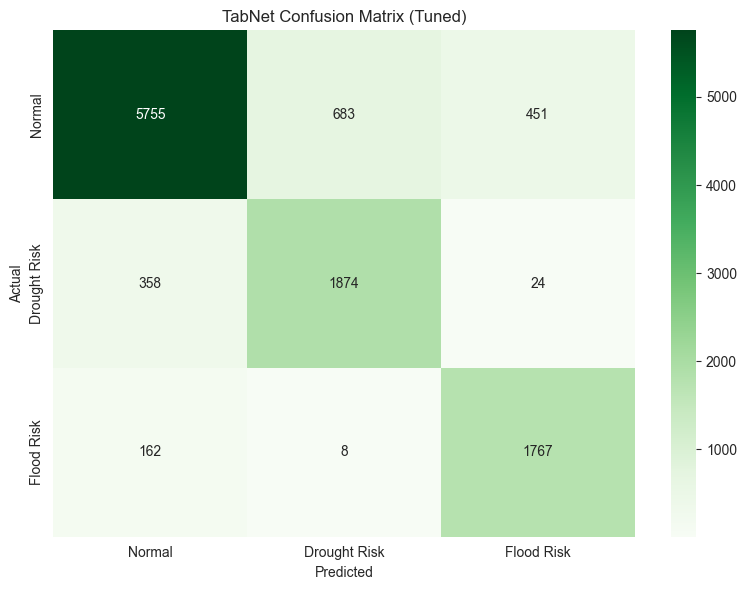

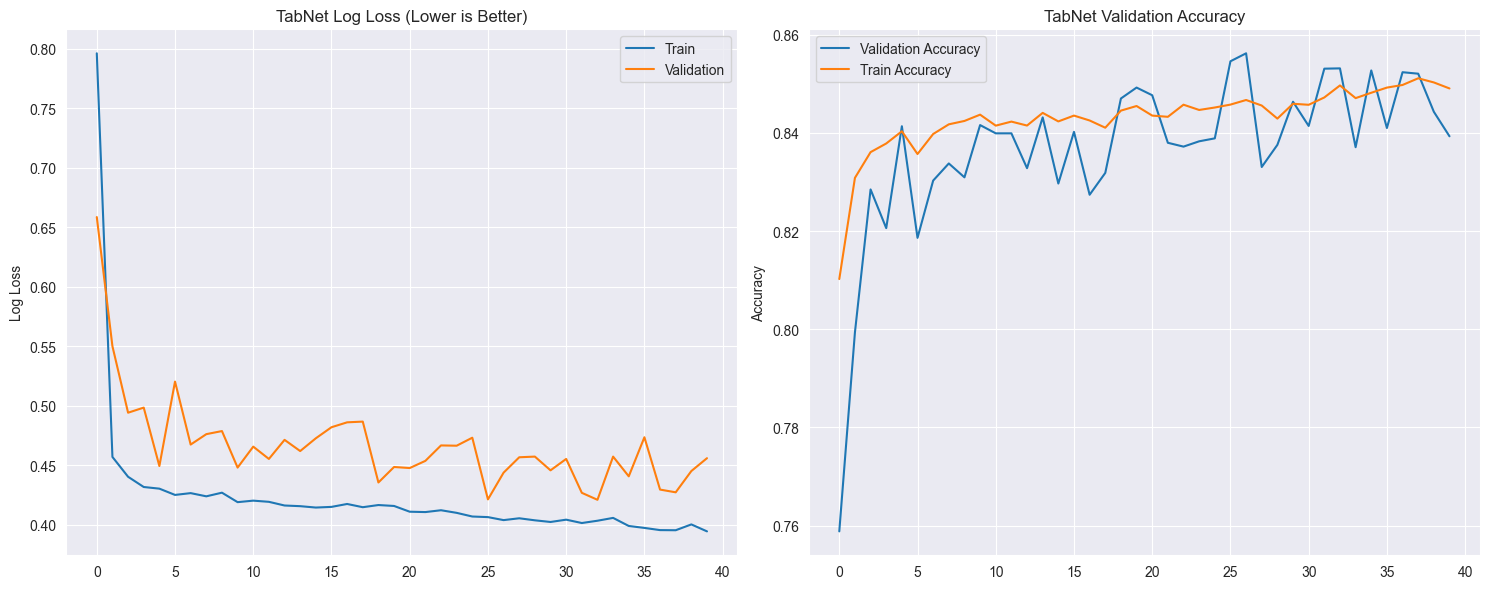

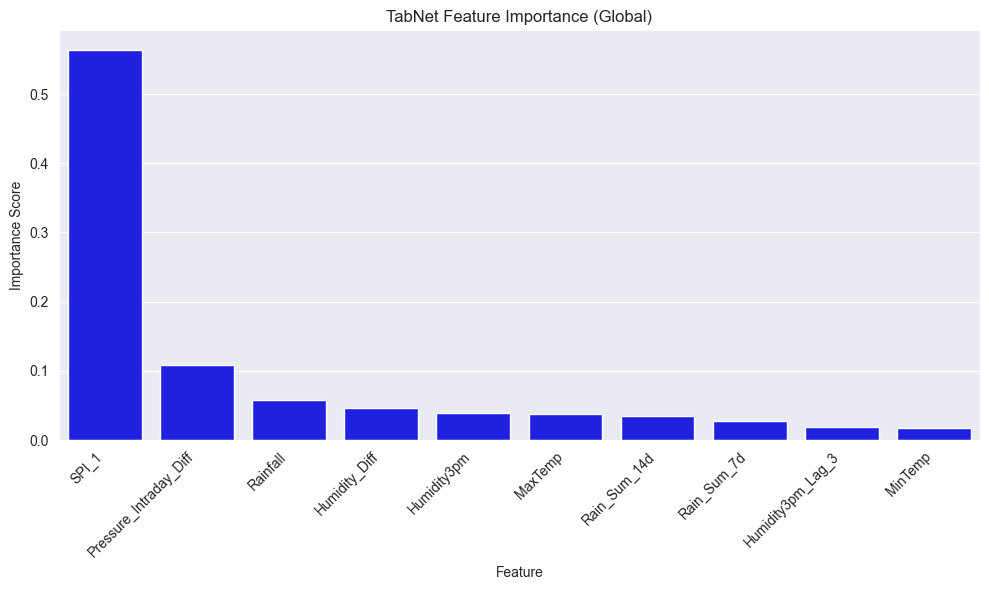

Files saved successfully!


In [18]:
# Predict on Test
y_pred = tabnet_model_tuned.predict(X_test_np)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')

# Predict on Train
y_train_pred = tabnet_model_tuned.predict(X_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

#Result
print("Result")
print(f"Test Accuracy : {test_acc:.2%}")
print(f"Test  F1-Macro: {test_f1:.4f}\n")

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Drought Risk', 'Flood Risk']
))


print(f"\nOverfitting Check")
print("-" * 35)
print(f"Train Accuracy :   {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}")
print("-" * 35)
print(f"Train F1-Macro: {train_f1:.4f}")
print(f"Test  F1-Macro: {test_f1:.4f}")
print("-" * 35)

print("\nTabnet Confusion Matrix...")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Drought Risk', 'Flood Risk'],
            yticklabels=['Normal', 'Drought Risk', 'Flood Risk'])
plt.title('TabNet Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


#Learnign Curve
history = tabnet_model_tuned.history.history
epochs_ran = len(history['loss'])
x_axis = range(epochs_ran)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Log Loss Plot
ax[0].plot(x_axis, history['loss'], label='Train')

if 'valid_logloss' in history:
    ax[0].plot(x_axis, history['valid_logloss'], label='Validation')

ax[0].legend()
ax[0].set_ylabel('Log Loss')
ax[0].set_title('TabNet Log Loss (Lower is Better)')
ax[0].grid(True)

# 2. Accuracy Plot
if 'valid_accuracy' in history:
    ax[1].plot(x_axis, history['valid_accuracy'], label='Validation Accuracy')

ax[1].plot(x_axis, history['train_accuracy'], label='Train Accuracy')
ax[1].legend()
ax[1].set_ylabel('Accuracy')
ax[1].set_title('TabNet Validation Accuracy')
ax[1].grid(True)

plt.tight_layout()
plt.show()


#Feature Importance
feat_importances = tabnet_model_tuned.feature_importances_
feature_names = list(X_train.columns)
indices = np.argsort(feat_importances)[::-1]
imp_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': feat_importances[indices]
})
top_10_df = imp_df.head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Importance', data=top_10_df, color='blue')
plt.title('TabNet Feature Importance (Global)')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Saving
joblib.dump(tabnet_model_tuned, '../model/tabnet_model_spi.pkl')
joblib.dump(scaler, '../model/tabnet_scaler.pkl')
model_columns = list(X_train.columns)
joblib.dump(model_columns, '../model/tabnet_columns.pkl')
print("Files saved successfully!")

plt.close('all')


### Comparison Bar Chart

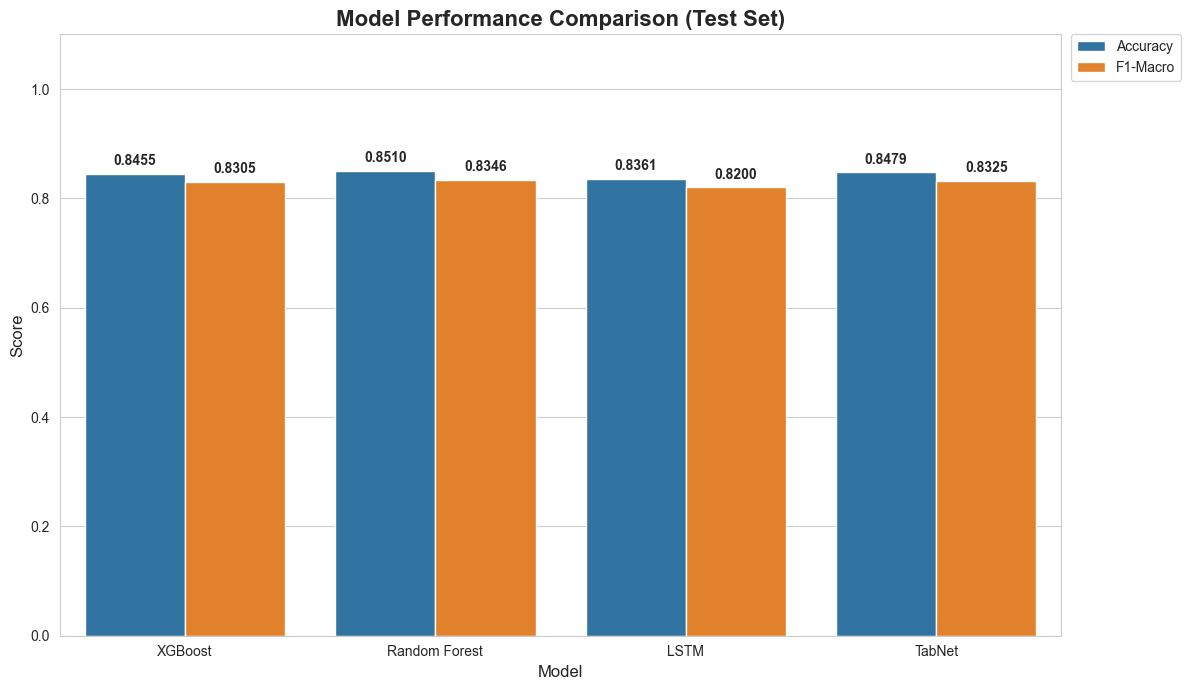

           Model  Accuracy  F1-Macro
0        XGBoost  0.845515  0.830496
1  Random Forest  0.851020  0.834579
2           LSTM  0.836131  0.820042
3         TabNet  0.847861  0.832481


In [19]:
# 1. Initialize lists to store results
model_names = ['XGBoost', 'Random Forest', 'LSTM', 'TabNet']
accuracies = []
f1_scores = []

#  XGBoost 
y_pred_xgb = xgb_model_tuned.predict(X_test)
accuracies.append(accuracy_score(y_test, y_pred_xgb))
f1_scores.append(f1_score(y_test, y_pred_xgb, average='macro'))

#  Random Forest 
y_pred_rf = RandomForest_tuned.predict(X_test)
accuracies.append(accuracy_score(y_test, y_pred_rf))
f1_scores.append(f1_score(y_test, y_pred_rf, average='macro'))

#  LSTM
y_pred_prob_lstm = lstm_model_tuned.predict(X_test_lstm, verbose=0)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)
accuracies.append(accuracy_score(y_test, y_pred_lstm))
f1_scores.append(f1_score(y_test, y_pred_lstm, average='macro'))

#  TabNet 
y_pred_tabnet = tabnet_model_tuned.predict(X_test_np)
accuracies.append(accuracy_score(y_test, y_pred_tabnet))
f1_scores.append(f1_score(y_test, y_pred_tabnet, average='macro'))

# 2. Create DataFrame
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'F1-Macro': f1_scores
})

# Melt the DataFrame for Seaborn
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create Bar Plot
ax = sns.barplot(
    data=comparison_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette=['#1f77b4', '#ff7f0e']
)

# Customization
plt.title('Model Performance Comparison (Test Set)', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.1)  # Set limit slightly above 1 for text labels
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Add numeric labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            format(p.get_height(), '.4f'),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

# Display the raw table
print(comparison_df)

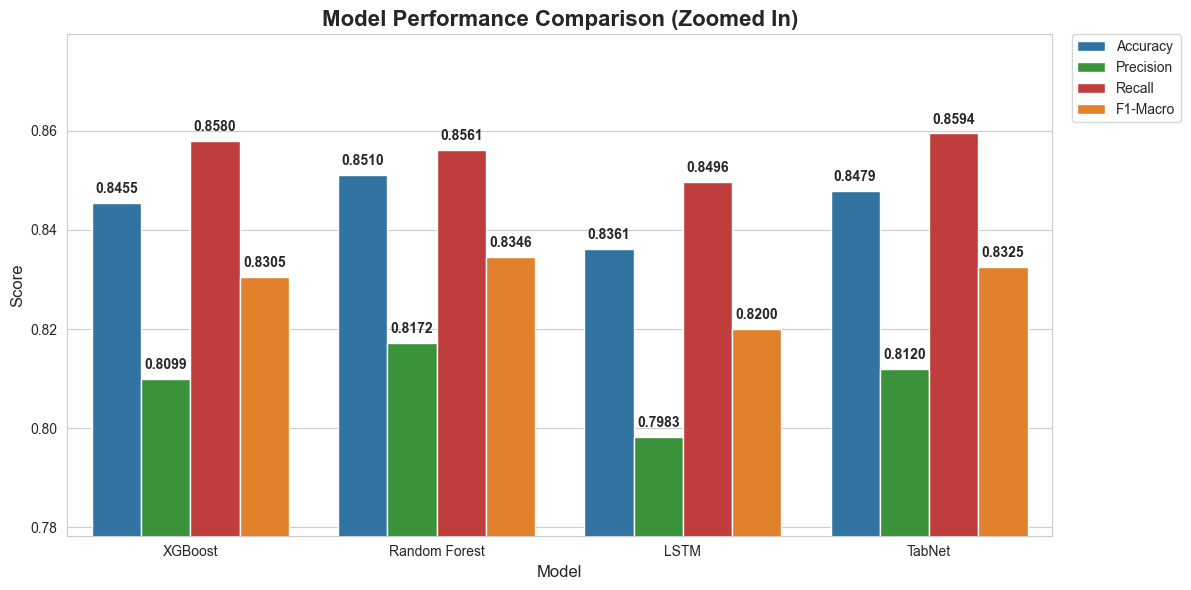

In [20]:
# 1. Initialize lists to store results
model_names = ['XGBoost', 'Random Forest', 'LSTM', 'TabNet']
accuracies = []
precisions = []  # New list
recalls = []     # New list
f1_scores = []

# --- XGBoost ---
y_pred_xgb = xgb_model_tuned.predict(X_test)
accuracies.append(accuracy_score(y_test, y_pred_xgb))
precisions.append(precision_score(y_test, y_pred_xgb, average='macro'))
recalls.append(recall_score(y_test, y_pred_xgb, average='macro'))
f1_scores.append(f1_score(y_test, y_pred_xgb, average='macro'))

# --- Random Forest ---
y_pred_rf = RandomForest_tuned.predict(X_test)
accuracies.append(accuracy_score(y_test, y_pred_rf))
precisions.append(precision_score(y_test, y_pred_rf, average='macro'))
recalls.append(recall_score(y_test, y_pred_rf, average='macro'))
f1_scores.append(f1_score(y_test, y_pred_rf, average='macro'))

# --- LSTM ---
y_pred_prob_lstm = lstm_model_tuned.predict(X_test_lstm, verbose=0)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)
accuracies.append(accuracy_score(y_test, y_pred_lstm))
precisions.append(precision_score(y_test, y_pred_lstm, average='macro'))
recalls.append(recall_score(y_test, y_pred_lstm, average='macro'))
f1_scores.append(f1_score(y_test, y_pred_lstm, average='macro'))

# --- TabNet ---
y_pred_tabnet = tabnet_model_tuned.predict(X_test_np)
accuracies.append(accuracy_score(y_test, y_pred_tabnet))
precisions.append(precision_score(y_test, y_pred_tabnet, average='macro'))
recalls.append(recall_score(y_test, y_pred_tabnet, average='macro'))
f1_scores.append(f1_score(y_test, y_pred_tabnet, average='macro'))

# 2. Create DataFrame with all metrics
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Macro': f1_scores
})

# Melt the DataFrame for Seaborn (Long format)
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Calculate limits to zoom in (min value - buffer, max value + buffer)
min_score = comparison_melted['Score'].min()
max_score = comparison_melted['Score'].max()
y_lower = min_score - 0.02
y_upper = max_score + 0.02

ax = sns.barplot(
    data=comparison_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']
)

plt.title('Model Performance Comparison ', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# CRITICAL CHANGE: Set the Y-axis limits to zoom in
plt.ylim(y_lower, y_upper)

# Legend placement
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Add numeric labels
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            format(p.get_height(), '.4f'),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()